# File Dokumen: Data Understanding Cuaca Bandung.ipynb
file ini berisi tentang data understanding cuaca di Bandung, Indonesia. Data ini mencakup informasi tentang suhu, kelembapan, curah hujan, dan parameter cuaca lainnya. Tujuan dari data understanding ini adalah untuk memahami struktur data, mengidentifikasi pola, dan menemukan insight yang dapat membantu dalam analisis lebih lanjut sebelum mulai olah data. Data ini dapat digunakan untuk memantau tren cuaca, menganalisis faktor-faktor yang mempengaruhi kondisi cuaca, dan membuat prediksi cuaca di masa depan.

Keterangan:
- 8888: Data tidak terukur
- 9999: Tidak Ada Data (tidak dilakukan pengukuran)
- "Tn: Temperatur minimum	(°C)"
- "Tx: Temperatur maksimum(°C)"
- "Tavg: Temperatur rata-rata(°C)"
- "RH_avg: Kelembapan rata-rata(%)"
- "RR: Curah hujan(mm)"
- "ss: Lamanya penyinaran matahari(jam)"
- "ff_x: Kecepatan angin maksimum(m/s)"
- "ddd_x: Arah angin saat kecepatan maksimum(°)"
- "ff_avg: Kecepatan angin rata-rata(m/s)"
- "ddd_car: Arah angin terbanyak(°)"


## Import Dataset

In [1]:
import os
import pandas as pd

path1 = 'dataset/Cuaca_Bandung_Cleaned.csv'
path2 = '../dataset/Cuaca_Bandung_Cleaned.csv'

if os.path.exists(path1):
    path = path1
elif os.path.exists(path2):
    path = path2
else:
    raise FileNotFoundError("Neither file path exists.")

df_cuacabandung = pd.read_csv(path)
df_cuacabandung.info()

<class 'pandas.DataFrame'>
RangeIndex: 727 entries, 0 to 726
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TANGGAL  727 non-null    str    
 1   TN       727 non-null    float64
 2   TX       727 non-null    float64
 3   TAVG     727 non-null    float64
 4   RH_AVG   727 non-null    float64
 5   RR       727 non-null    float64
 6   SS       727 non-null    float64
 7   FF_X     727 non-null    float64
 8   DDD_X    727 non-null    float64
dtypes: float64(8), str(1)
memory usage: 51.2 KB


**Penjelasan:**
Langkah ini mengimpor pustaka (library) yang diperlukan seperti `os` dan `pandas`. Kemudian, membaca dataset cuaca harian kota Bandung dari file CSV menggunakan `pd.read_csv()`. Fungsi `df_cuacabandung.info()` dipanggil untuk menampilkan informasi ringkas mengenai dataset, termasuk jumlah baris, jumlah kolom, tipe data setiap kolom, serta mendeteksi apakah ada nilai kosong (*missing values*) secara umum.\

In [5]:
df_cuacabandung.set_index('TANGGAL', inplace=True)

df_cuacabandung.head(10)

,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X
TANGGAL,,,,,,,,
2025-01-01,21.6,32.8,25.0,75.0,3.5,1.3,4.0,270.0
2025-01-02,21.2,33.4,25.9,60.0,3.5,6.5,6.0,233.0
2025-01-03,21.2,32.8,26.3,73.0,0.3,8.0,3.0,290.0
2025-01-04,22.0,31.8,25.0,75.0,0.0,8.0,3.0,260.0
2025-01-05,22.0,30.6,25.6,72.0,3.2,5.3,2.0,260.0
2025-01-06,20.6,32.4,24.5,78.0,0.0,3.5,3.0,248.0
2025-01-07,20.2,31.0,28.2,69.0,26.9,5.7,5.0,270.0
2025-01-08,20.6,30.4,24.9,79.0,0.0,8.0,3.0,300.0
2025-01-09,22.2,26.4,23.2,86.0,2.2,3.5,3.0,300.0


**Penjelasan:**
Fungsi `head(10)` digunakan untuk menampilkan 10 baris pertama dari dataset. Hal ini bertujuan untuk memberikan gambaran sekilas mengenai format dan isi data dari masing-masing variabel (seperti TANGGAL, TN, TX, TAVG, RH_AVG, RR, dll) sebelum melakukan tahapan analisis lebih lanjut.\

## Analisis Univariat (Distribusi Data)

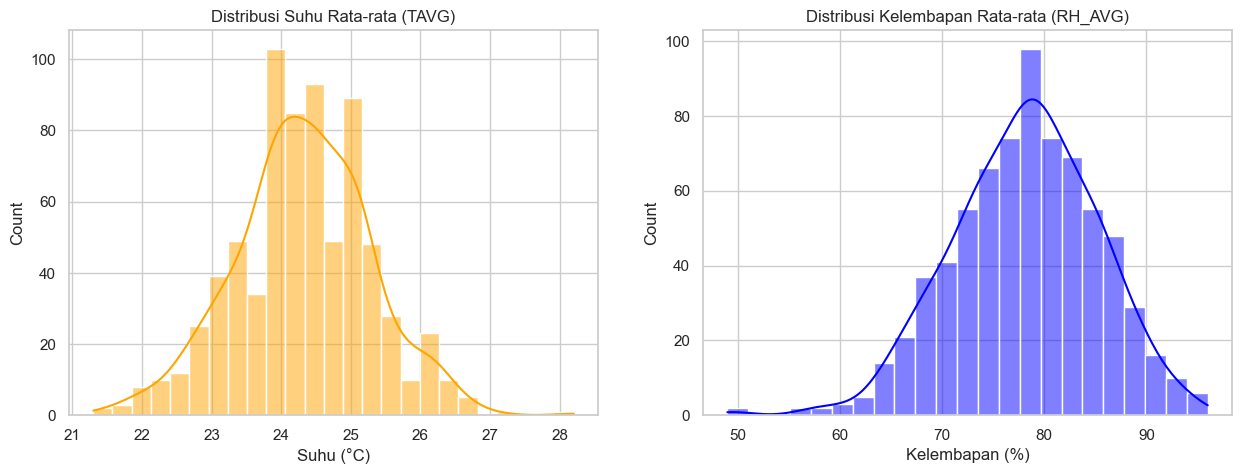

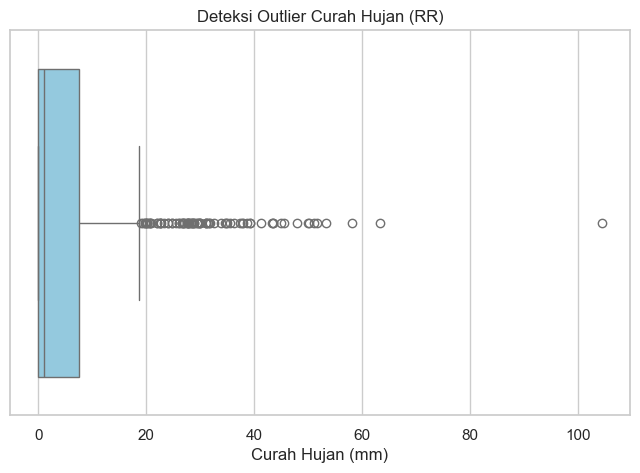

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema plot
sns.set_theme(style="whitegrid")

# 1. Histogram Distribusi Suhu Rata-rata dan Kelembapan
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_cuacabandung['TAVG'], kde=True, color='orange', ax=ax[0])
ax[0].set_title('Distribusi Suhu Rata-rata (TAVG)')
ax[0].set_xlabel('Suhu (°C)')

sns.histplot(df_cuacabandung['RH_AVG'], kde=True, color='blue', ax=ax[1])
ax[1].set_title('Distribusi Kelembapan Rata-rata (RH_AVG)')
ax[1].set_xlabel('Kelembapan (%)')
plt.show()

# 2. Boxplot untuk melihat Outlier pada Curah Hujan (RR)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_cuacabandung['RR'], color='skyblue')
plt.title('Deteksi Outlier Curah Hujan (RR)')
plt.xlabel('Curah Hujan (mm)')
plt.show()


**Penjelasan:**
Tahap Analisis Univariat digunakan untuk melihat distribusi masing-masing variabel secara individual:
1. **Histogram** menunjukkan bagaimana penyebaran data suhu rata-rata (TAVG) dan kelembapan (RH_AVG). Garis *KDE (Kernel Density Estimate)* membantu memvisualisasikan bentuk kurva distribusi.
2. **Boxplot** curah hujan (RR) digunakan untuk mengidentifikasi keberadaan *outlier* (pencilan). Titik-titik di luar "kumis" (garis batas) pada boxplot menandakan hari-hari dengan intensitas curah hujan lebat yang tidak biasa atau ekstrem.\

## Analisis Multivariat (Korelasi Antar Variabel)

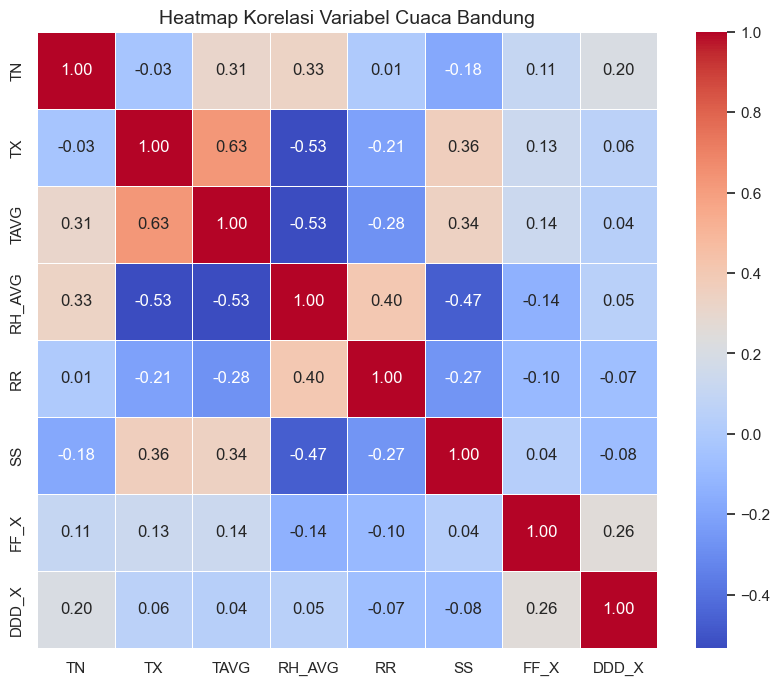

In [7]:
plt.figure(figsize=(10, 8))

# Menghitung korelasi antar variabel cuaca
korelasi = df_cuacabandung.corr()

# Membuat Heatmap
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Variabel Cuaca Bandung', fontsize=14)
plt.show()


**Penjelasan:**
Tahap Analisis Multivariat menggunakan matriks korelasi (*correlation matrix*) yang divisualisasikan dalam bentuk **Heatmap**.
Angka korelasi berkisar antara -1 hingga 1:
- Mendekati 1: Hubungan positif kuat (kedua variabel naik bersamaan).
- Mendekati -1: Hubungan negatif kuat (satu naik, yang lain turun).
- Mendekati 0: Tidak ada hubungan linier yang signifikan.
Visualisasi ini memudahkan dalam menemukan variabel mana saja yang saling mempengaruhi satu sama lain (misalnya, kemungkinan hubungan antara kelembapan dan intensitas curah hujan).\

## Analisis Deret Waktu (Time Series)

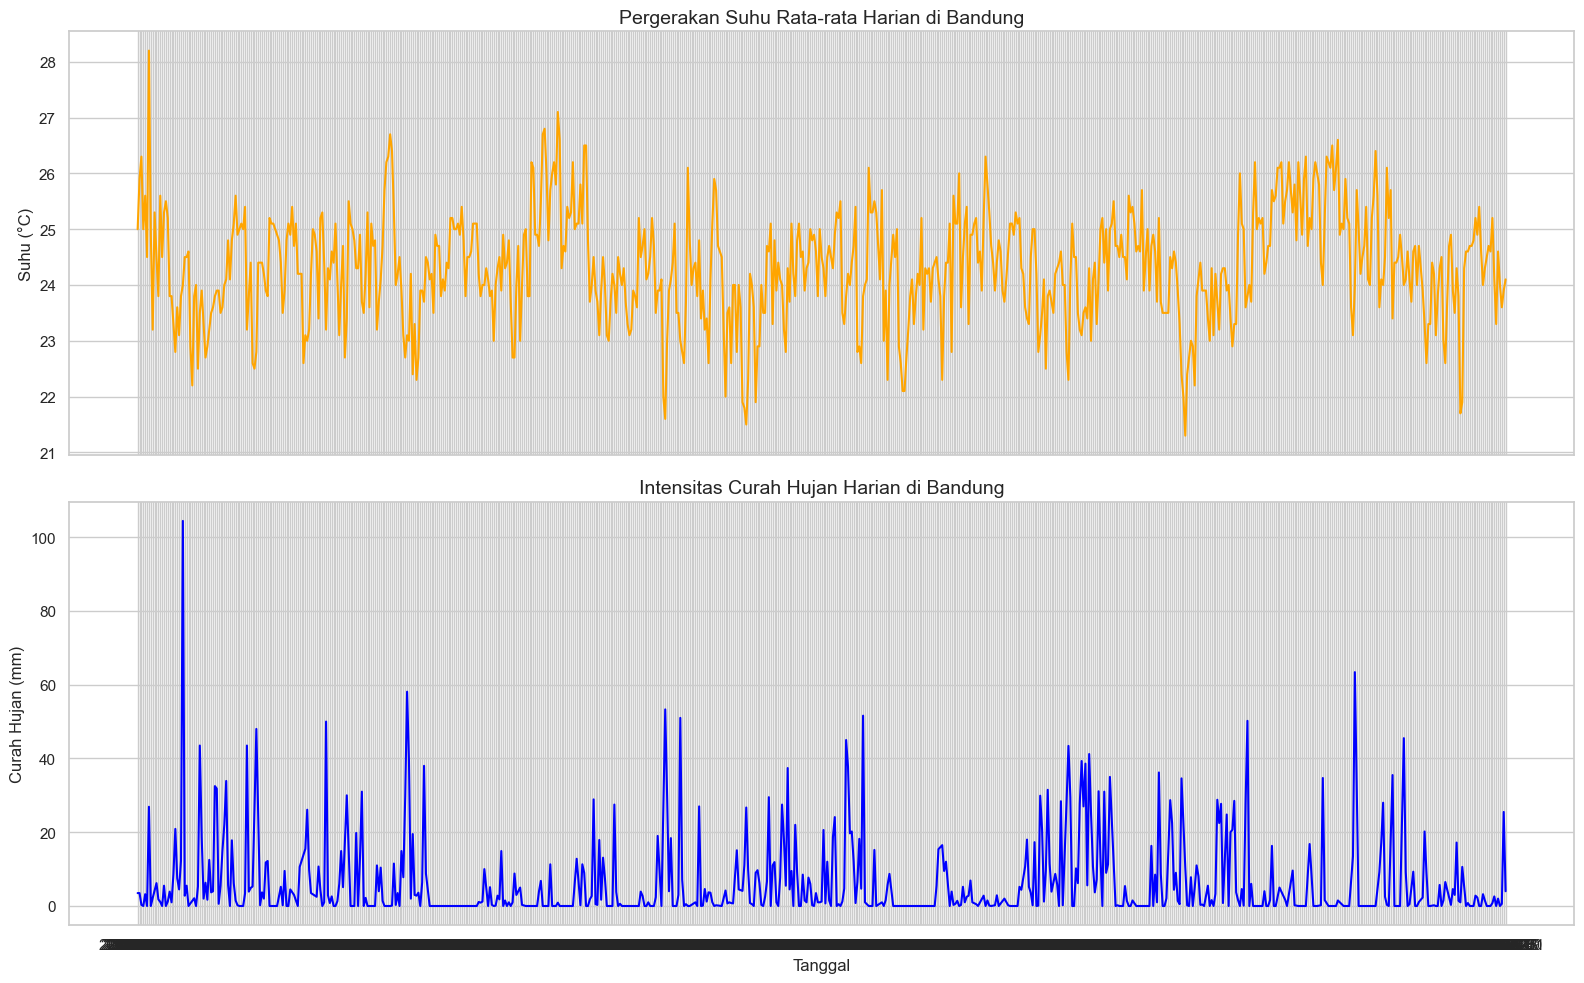

In [8]:
# Membuat plot pergerakan Suhu dan Curah hujan sepanjang waktu
fig, ax = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Plot Suhu Rata-Rata (TAVG)
sns.lineplot(data=df_cuacabandung, x=df_cuacabandung.index, y='TAVG', ax=ax[0], color='orange', linewidth=1.5)
ax[0].set_title('Pergerakan Suhu Rata-rata Harian di Bandung', fontsize=14)
ax[0].set_ylabel('Suhu (°C)')

# Plot Curah Hujan (RR)
sns.lineplot(data=df_cuacabandung, x=df_cuacabandung.index, y='RR', ax=ax[1], color='blue', linewidth=1.5)
ax[1].set_title('Intensitas Curah Hujan Harian di Bandung', fontsize=14)
ax[1].set_ylabel('Curah Hujan (mm)')
ax[1].set_xlabel('Tanggal')

plt.tight_layout()
plt.show()


**Penjelasan:**
Tahap Analisis Deret Waktu (*Time Series*) digunakan untuk melihat pola perubahan variabel dari waktu ke waktu:
- **Plot Suhu Rata-rata** memperlihatkan fluktuasi harian suhu di kota Bandung selama periode data. Ini membantu menemukan tren perubahan cuaca.
- **Plot Curah Hujan** menunjukkan dinamika turunnya hujan setiap hari, sehingga kita dapat melihat kapan curah hujan mencapai puncaknya (musim hujan) dan kapan wilayah tersebut mengalami hari tanpa hujan (kemarau).\

## Kesimpulan Data Understanding

Berdasarkan keseluruhan proses *Data Understanding* dan *Exploratory Data Analysis (EDA)* yang telah dilakukan pada dataset cuaca Bandung, dapat ditarik beberapa kesimpulan:
1. **Kondisi Data Awal:** Dataset memiliki beberapa anomali pengukuran, seperti nilai `8888` dan `9999`. Ini berhasil ditangani dengan mengubahnya menjadi nilai kosong (`NaN`) dan dilanjutkan dengan teknik interpolasi linier, sehingga integritas data untuk analisis deret waktu tetap terjaga.
2. **Karakteristik Cuaca (Univariat):** Suhu rata-rata dan kelembapan di Bandung cenderung mengikuti suatu distribusi terpusat. Untuk curah hujan, terdapat beberapa nilai *outlier* atas yang mencerminkan kejadian curah hujan lebat secara tiba-tiba di hari-hari tertentu.
3. **Hubungan Variabel (Multivariat):** Beberapa parameter cuaca menunjukkan tingkat korelasi satu sama lain (dapat dilihat dari pola *heatmap*). Pengetahuan ini berguna untuk tahap analisis lebih lanjut dan pemodelan dalam menemukan pendorong utama turunnya hujan, contohnya seperti tingkat kelembapan rata-rata (RH_AVG) maupun komponen lain.
4. **Pola Waktu (Time Series):** Visualisasi suhu dan curah hujan harian menunjukkan adanya dinamika cuaca yang fluktuatif sepanjang waktu observasi, memperlihatkan fluktuasi antara kemarau dan hujan lebat. 

Dengan data yang sudah dibersihkan dan pemahaman yang lebih baik tentang karakteristik setiap variabel, dataset ini sudah siap untuk digunakan pada tahap *Data Preparation* lanjutan atau pemodelan *Data Mining* (misalnya untuk klasifikasi atau prediksi intensitas cuaca).\